In [1]:
import seaborn as sns
from matplotlib import pyplot as plt
import pickle as pkl
from scipy import stats
import numpy as np
from glob import glob

In [2]:
from communication_subspace.ibl_communication.plotting import *

In [3]:
%load_ext autoreload
%autoreload 2

In [4]:
files = glob("../data/simple_ridge_results/*.pkl")

In [7]:
# check inputs
data_dict = {}
for idx, fileidx in enumerate(files):
    with open(fileidx, "rb") as f:
        eid_data = pkl.load(f)
        cross_array_prediction_high, cross_array_prediction_low = eid_data[
            "ridge_regression_dict"
        ][(0, 1)]
    data_dict[f"mouse={idx}"] = {
        "high": cross_array_prediction_high,
        "low": cross_array_prediction_low,
    }

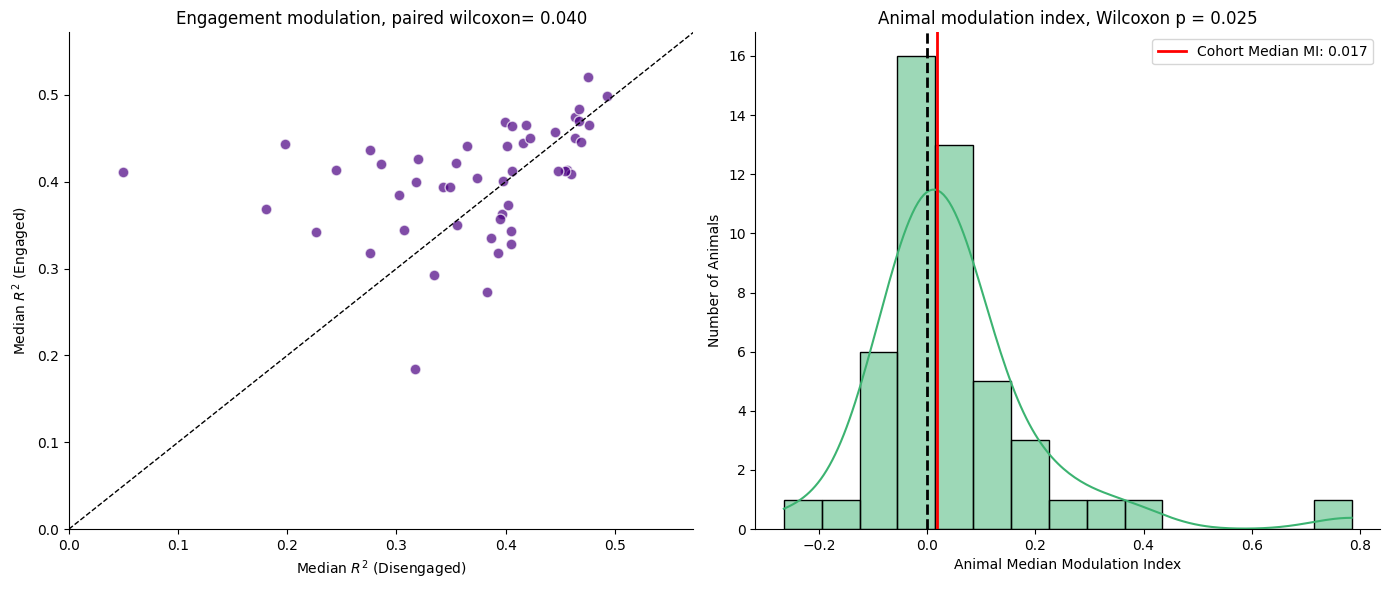

In [8]:
aggregate_and_plot_cohort(data_dict, r2_threshold=0.3)

In [28]:
# check inputs
data_dict = {}
for idx, fileidx in enumerate(files):
    with open(fileidx, "rb") as f:
        eid_data = pkl.load(f)
        cross_array_prediction_high, cross_array_prediction_low = eid_data[
            "ridge_regression_dict"
        ][(0, 1)]
    data_dict[f"mouse-{idx}"] = {
        "high_r2": cross_array_prediction_high,
        "low_r2": cross_array_prediction_low,
        "regions": [r[0] for r in eid_data["regions"]],
    }

In [ ]:
def generate_module_dict(flat_regions):
    """
    Uses the IBL BrainRegions tree to dynamically assign
    specific sub-regions to their parent macro-modules.
    """
    br = BrainRegions() # type: ignore
    target_parents = ["VIS", "MO", "SS", "AUD", "ACA", "RSP", "PL", "TEa", "MOB"]

    module_dict = {parent: [] for parent in target_parents}
    module_dict["Other"] = []


    region_ids = br.acronym2id(flat_regions)

    for reg_acronym, reg_id in zip(flat_regions, region_ids):

        if reg_id is None:
            continue


        ancestry = br.ancestors(reg_id)
        lineage_acronyms = ancestry["acronym"]

        assigned = False
        for parent in target_parents:
            if parent in lineage_acronyms:
                module_dict[parent].append(reg_acronym)
                assigned = True
                break  # Stop searching once we find the parent

        if not assigned:
            module_dict["Other"].append(reg_acronym)


    return {k: v for k, v in module_dict.items() if len(v) > 0}


# --- Let's test it on your list! ---
regionsx = [r[0] for r in eid_data["regions"]]
regions = regionsx
allen_modules = generate_module_dict(regions)

/Users/dkundu/Documents/phd/communication_python/communication_subspace/ibl_communication/plotting.py:263: RuntimeWarning: Mean of empty slice
  group_mean_high = np.nanmean(stack_high, axis=0)
/Users/dkundu/Documents/phd/communication_python/communication_subspace/ibl_communication/plotting.py:264: RuntimeWarning: Mean of empty slice
  group_mean_low = np.nanmean(stack_low, axis=0)


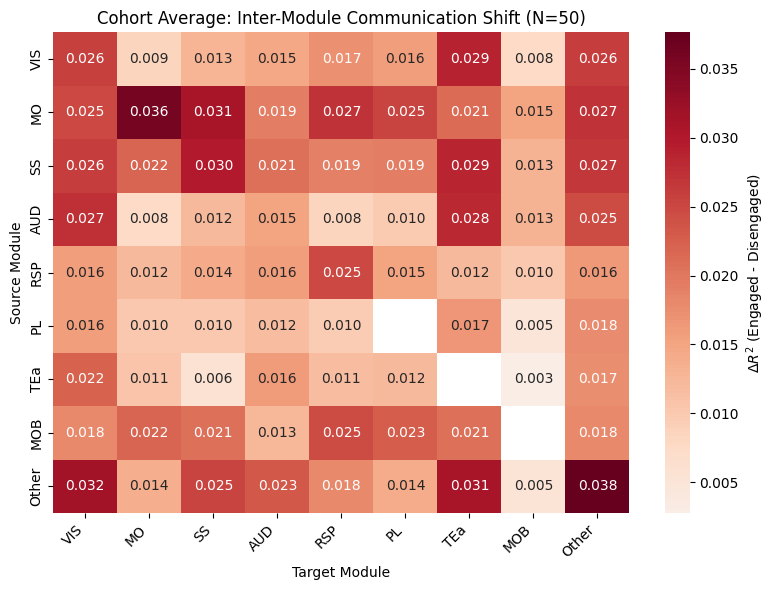

In [ ]:
process_cohort_modules(data_dict, allen_modules, )

In [34]:
from iblatlas.atlas import BrainRegions

In [35]:
br = BrainRegions()

In [43]:
br.ancestors(br.acronym2id(regionsx[0]))

{'id': array([997,   8, 567, 688, 695, 698, 507]),
 'name': array(['root', 'Basic cell groups and regions', 'Cerebrum',
        'Cerebral cortex', 'Cortical plate', 'Olfactory areas',
        'Main olfactory bulb'], dtype=object),
 'acronym': array(['root', 'grey', 'CH', 'CTX', 'CTXpl', 'OLF', 'MOB'], dtype=object),
 'rgb': array([[255, 255, 255],
        [191, 218, 227],
        [176, 240, 255],
        [176, 255, 184],
        [112, 255, 112],
        [154, 210, 189],
        [154, 210, 189]], dtype=uint8),
 'level': array([0, 1, 2, 3, 4, 5, 6], dtype=uint16),
 'parent': array([ nan, 997.,   8., 567., 688., 695., 698.]),
 'order': array([  0,   1,   2,   3,   4, 379, 380], dtype=uint16)}

In [ ]:
br.ac

Signature: br.compute_hierarchy()
Docstring:
Creates a self.hierarchy attribute that is an n_levels by n_region array
of indices. This is useful to perform fast vectorized computations of
ancestors and descendants.
:return:
File:      ~/mamba/envs/info-decom/lib/python3.10/site-packages/iblatlas/regions.py
Type:      method

In [1]:
# load single session , look at timeouts